In [56]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier



In [57]:
df = pd.read_csv(r"c:\Users\AsgharAli Thomas\Documents\RFID2\ds_Tx_Rx(1).csv")
df.shape

(4411, 292)

In [58]:
print(df.columns[:180])

Index(['EPC', 'xyz', 'max__rssi__24.0__041A9F60__NONE__PORT_1__NONE',
       'max__rssi__24.0__041A9F60__NONE__PORT_2__NONE',
       'max__rssi__24.0__041A9F60__NONE__PORT_3__NONE',
       'max__rssi__24.0__041A9F60__NONE__PORT_4__NONE',
       'max__rssi__24.0__041A9F61__NONE__PORT_1__NONE',
       'max__rssi__24.0__041A9F61__NONE__PORT_2__NONE',
       'max__rssi__24.0__041A9F61__NONE__PORT_3__NONE',
       'max__rssi__24.0__041A9F61__NONE__PORT_4__NONE',
       ...
       'max__Delta_rssi__27.0__041A9F61__NONE__PORT_1__NONE|PORT_2__NONE',
       'max__Delta_rssi__27.0__041A9F61__NONE__PORT_1__NONE|PORT_3__NONE',
       'max__Delta_rssi__27.0__041A9F61__NONE__PORT_1__NONE|PORT_4__NONE',
       'max__Delta_rssi__27.0__041A9F61__NONE__PORT_2__NONE|PORT_1__NONE',
       'max__Delta_rssi__27.0__041A9F61__NONE__PORT_2__NONE|PORT_3__NONE',
       'max__Delta_rssi__27.0__041A9F61__NONE__PORT_2__NONE|PORT_4__NONE',
       'max__Delta_rssi__27.0__041A9F61__NONE__PORT_3__NONE|PORT_1__NONE',
  

In [59]:
if "xyz" in df.columns:
    xyz_split = df["xyz"].astype(str).str.split("__", expand=True)
    if xyz_split.shape[1] >= 3:
        df[["x", "y", "z"]] = xyz_split.iloc[:, :3]

required = ["x", "y", "z"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Colonnes manquantes dans df: {missing}")

for c in required:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=required).copy()
df = df.reset_index(drop=True)

print("Shape df:", df.shape)
df[["x", "y", "z"]].head()

Shape df: (4411, 292)


,x,y,z
0,1.82,2.51,0.05
1,10.10,3.82,1.29
2,10.34,3.33,0.05
3,10.51,3.26,0.05
4,10.71,3.92,1.57


In [60]:
df.columns[180:200]

Index(['max__Delta_rssi__27.0__041A9F61__NONE__PORT_4__NONE|PORT_2__NONE',
       'max__Delta_rssi__27.0__041A9F61__NONE__PORT_4__NONE|PORT_3__NONE',
       'max__Delta_rssi__27.0__0F173B12__NONE__PORT_1__NONE|PORT_2__NONE',
       'max__Delta_rssi__27.0__0F173B12__NONE__PORT_1__NONE|PORT_3__NONE',
       'max__Delta_rssi__27.0__0F173B12__NONE__PORT_1__NONE|PORT_4__NONE',
       'max__Delta_rssi__27.0__0F173B12__NONE__PORT_2__NONE|PORT_1__NONE',
       'max__Delta_rssi__27.0__0F173B12__NONE__PORT_2__NONE|PORT_3__NONE',
       'max__Delta_rssi__27.0__0F173B12__NONE__PORT_2__NONE|PORT_4__NONE',
       'max__Delta_rssi__27.0__0F173B12__NONE__PORT_3__NONE|PORT_1__NONE',
       'max__Delta_rssi__27.0__0F173B12__NONE__PORT_3__NONE|PORT_2__NONE',
       'max__Delta_rssi__27.0__0F173B12__NONE__PORT_3__NONE|PORT_4__NONE',
       'max__Delta_rssi__27.0__0F173B12__NONE__PORT_4__NONE|PORT_1__NONE',
       'max__Delta_rssi__27.0__0F173B12__NONE__PORT_4__NONE|PORT_2__NONE',
       'max__Delta_rssi__

In [61]:

h = 1  # taille du voxel

for c in ["x", "y", "z"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["x", "y", "z"]).copy()

df["i"] = np.floor(df["x"] / h).astype(int)
df["j"] = np.floor(df["y"] / h).astype(int)
df["k"] = np.floor(df["z"] / h).astype(int)

Nx = df["i"].max() + 1 # nombres de voxels en x, y, z
Ny = df["j"].max() + 1
Nk = df["k"].max() + 1

df["class_id"] = df["i"] + Nx * df["j"] + Nx * Ny * df["k"]
target = df["class_id"]
### voxels




X = df.drop(columns=[
    "i",
    "j",
    "k",
    "class_id",
    "x",
    "y",
    "z",
    "xyz",
    'polar',
    'nearestAnt',
    'D_041A9F60',
    'D_041A9F61',
    'D_0F17B312',
    'D_0F17B313',
    'D_PORT_1',
    'D_PORT_2',
    'D_PORT_3'
    'D_PORT_4',
    'D_nearestAnt'
    'nearestD'
    
    # es ce que il y en a dautre a enlever ? ???? 
], errors="ignore")

# Retirer toutes les colonnes non numeriques pour eviter l erreur du scaler
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
X = X.drop(columns=non_numeric_cols, errors="ignore")


# Anti-fuite: ne garder que les vraies features RSSI
rssi_cols = [c for c in df.columns if c.startswith("max__Delta_rssi")]
if not rssi_cols:
    raise ValueError("Aucune colonne RSSI trouvee (prefixe max__Delta_rssi)")

X_small = df[rssi_cols].copy()

print("Nombre de classes :", target.nunique())
print("Nombre final de features RSSI :", X.shape[1])
print("Nombre de features RSSI selectionnees :", X_small.shape[1])

Nombre de classes : 74
Nombre final de features RSSI : 285
Nombre de features RSSI selectionnees : 180


In [ ]:
print(*X_train.columns, sep="\n")

In [62]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)


print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (3528, 285)
Test: (883, 285)


In [63]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_features = X_train_scaled.shape[1]
num_classes = target.nunique()

print("num_features =", num_features)
print("num_classes =", num_classes)

num_features = 285
num_classes = 74


In [64]:
def decode_class_id(class_id, Nx, Ny):
    k = class_id // (Nx * Ny)
    remainder = class_id % (Nx * Ny)

    j = remainder // Nx
    i = remainder % Nx

    return i, j, k



def voxel_center(class_id, Nx, Ny, h):
    i, j, k = decode_class_id(class_id, Nx, Ny)

    x = (i + 0.5) * h
    y = (j + 0.5) * h
    z = (k + 0.5) * h

    return np.array([x, y, z])

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.model_selection import KFold

RLog_cv = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=53
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(RLog_cv, X_train, y_train, cv=cv)

print("CV accuracy scores:", cv_scores)
print("CV mean accuracy:", cv_scores.mean())

# entrainement final
RLog_cv.fit(X_train, y_train)

y_pred_cv = RLog_cv.predict(X_test)
acc_lr_cv = accuracy_score(y_test, y_pred_cv)

print("Test accuracy:", acc_lr_cv)

c:\Users\AsgharAli Thomas\Documents\RFID2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\AsgharAli Thomas\Documents\RFID2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.or

CV accuracy scores: [0.80028329 0.78611898 0.79886686 0.80141844 0.79574468]
CV mean accuracy: 0.7964864484760815
Test accuracy: 0.8221970554926388


c:\Users\AsgharAli Thomas\Documents\RFID2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [66]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

errors = []
predA3_cv = []
xyz_test_cv = []
for pred_id, true_xyz in zip(y_pred_cv, true_coords):

    pred_xyz_cv = voxel_center(pred_id, Nx, Ny, h)

    err = np.linalg.norm(true_xyz - pred_xyz_cv)

    errors.append(err)
    predA3_cv.append(pred_xyz_cv)
    xyz_test_cv.append(true_xyz)
errors = np.array(errors)
rmse_cv = float(np.sqrt(np.mean(errors ** 2)))

print("Erreur moyenne :", errors.mean())
print("RMSE :", rmse_cv)
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 0.5100476167951442
RMSE : 0.5572973124381062
Erreur mediane : 0.500899191454728
Erreur max : 3.089741089476592


In [67]:
coef_df = pd.DataFrame(
    RLog_cv.coef_,
    columns=X_train.columns
)
coef_df.max()

max__rssi__24.0__041A9F60__NONE__PORT_1__NONE    0.477937
max__rssi__24.0__041A9F60__NONE__PORT_2__NONE    0.173749
max__rssi__24.0__041A9F60__NONE__PORT_3__NONE    0.398172
max__rssi__24.0__041A9F60__NONE__PORT_4__NONE    0.169184
max__rssi__24.0__041A9F61__NONE__PORT_1__NONE    0.703719
                                                   ...   
PORT_1__NONE                                     3.077051
PORT_2__NONE                                     2.668390
PORT_3__NONE                                     3.102926
PORT_4__NONE                                     2.567838
nearestD                                         5.399497
Length: 285, dtype: float64

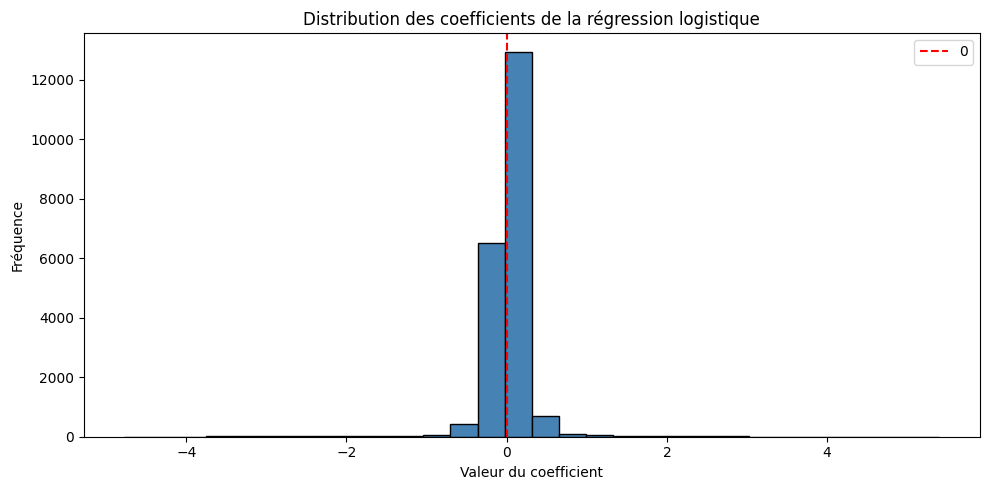

In [68]:


import matplotlib.pyplot as plt
import numpy as np

coef_vals = coef_df.values.flatten()

plt.figure(figsize=(10, 5))
plt.hist(coef_vals, bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution des coefficients de la régression logistique")
plt.xlabel("Valeur du coefficient")
plt.ylabel("Fréquence")
plt.axvline(0, color='red', linestyle='--', label='0')
plt.legend()
plt.tight_layout()
plt.show()


In [69]:
rows_diff = []

for class_true, class_pred, xyz_true, xyz_pred_cv in zip(
    np.asarray(y_test).astype(int),
    np.asarray(y_pred_cv).astype(int),
    xyz_test_cv,
    predA3_cv
):
    dx = float(xyz_pred_cv[0] - xyz_true[0])
    dy = float(xyz_pred_cv[1] - xyz_true[1])
    dz = float(xyz_pred_cv[2] - xyz_true[2])
    dist = float(np.linalg.norm([dx, dy, dz]))

    rows_diff.append({
        "class_id_true": int(class_true),
        "class_id_pred": int(class_pred),
        "x_true": float(xyz_true[0]),
        "y_true": float(xyz_true[1]),
        "z_true": float(xyz_true[2]),
        "x_pred": float(xyz_pred_cv[0]),
        "y_pred": float(xyz_pred_cv[1]),
        "z_pred": float(xyz_pred_cv[2]),
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

df_diff_cv = pd.DataFrame(rows_diff)

print("Nombre total de lignes:", len(df_diff_cv))

df_diff_cv_1p3m = df_diff_cv[df_diff_cv["distance"] > 1.5]
print("Nombre d erreurs > 1.3 m:", len(df_diff_cv_1p3m))

display(df_diff_cv_1p3m.head(20))

print(df_diff_cv_1p3m[[
    "class_id_true",
    "class_id_pred",
    "dx",
    "dy",
    "dz",
    "distance"
]].describe())

Nombre total de lignes: 883
Nombre d erreurs > 1.3 m: 1


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
440,116,20,8.56,4.52,1.15,8.5,1.5,0.5,-0.06,-3.02,-0.65,3.089741


       class_id_true  class_id_pred    dx    dy    dz  distance
count            1.0            1.0  1.00  1.00  1.00  1.000000
mean           116.0           20.0 -0.06 -3.02 -0.65  3.089741
std              NaN            NaN   NaN   NaN   NaN       NaN
min            116.0           20.0 -0.06 -3.02 -0.65  3.089741
25%            116.0           20.0 -0.06 -3.02 -0.65  3.089741
50%            116.0           20.0 -0.06 -3.02 -0.65  3.089741
75%            116.0           20.0 -0.06 -3.02 -0.65  3.089741
max            116.0           20.0 -0.06 -3.02 -0.65  3.089741
